In [1]:
# --- Libraries ---
import pandas as pd
import numpy as np
from datetime import datetime

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm

import matplotlib.pyplot as plt
import seaborn as sns

from fredapi import Fred
import os 
# --- Configuration ---
wd = r"C:\Users\Alejandro\Documents\MQuEA\TFM\data"
os.chdir(wd)


# Analisis series del petroleo

Importing data from Fred API...


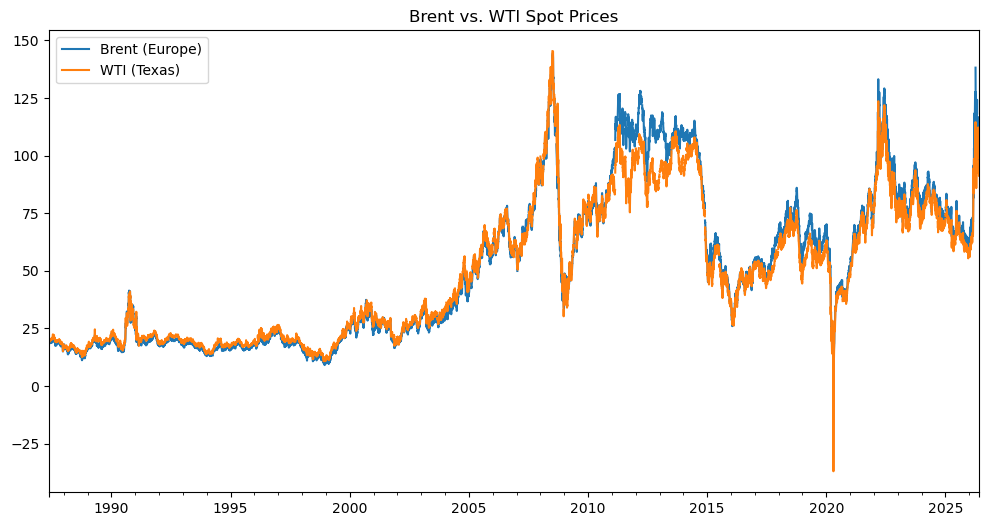

In [2]:
# ---------- Initialize FRED API client ----------
api_link = r"C:\Users\Alejandro\Documents\Documentos personales\Claves de recuperacion de cuentas y APIs\Fred API.txt"

# Open the file in read mode
with open(api_link, "r") as f:
    api_key = f.read().strip()

fred = Fred(api_key=api_key)

try:
    # Import data from Fred API 
    brent_eu = fred.get_series("DCOILBRENTEU")
    wti_texas = fred.get_series("DCOILWTICO")

    print("Importing data from Fred API...")
    
    # Concat in a single dataframe
    oil_prices = pd.concat([brent_eu.to_frame(), wti_texas.to_frame()], axis=1, join="inner")
    
    # Properly name the columns (WTI, not Brent Texas)
    oil_prices.columns = ["Brent (Europe)", "WTI (Texas)"]
    
    # ---------- Plotting the variables ----------
    oil_prices.plot(figsize=(12, 6), title="Brent vs. WTI Spot Prices")
    plt.show()

except Exception as e:
    # If the API fails, it prints this and STOPS, preventing a crash later
    print(f"Could not import the data. Incoming Exception: {e}")
    # Optional: You could add your local file fallback here like in your first script!

## Study of the Oil Shocks

In [3]:
brent_study= oil_prices["Brent (Europe)"].to_frame()
brent_study.head()

,Brent (Europe)
1987-05-20,18.63
1987-05-21,18.45
1987-05-22,18.55
1987-05-25,18.60
1987-05-26,18.63


Lets take a look at the last 5 great shocks in oil prices: 
1. 2007–2008: Demand‑Driven Shock from Emerging Economies
The rapid expansion of China and India generated an exceptional surge in global commodity demand. With oil supply unable to adjust quickly, Brent crude entered a strong upward trend, culminating in record prices in mid‑2008. This episode is widely characterized as a demand‑driven shock.

2. 2014–2016: Supply‑Driven Collapse Triggered by U.S. Shale and OPEC Strategy
A sharp increase in U.S. shale oil production, combined with OPEC’s strategic decision not to cut output, created a global supply glut. Brent prices fell dramatically, marking one of the steepest declines in modern oil market history.

3. 2020–2022: Pandemic‑Induced Demand Collapse
The COVID‑19 pandemic caused an unprecedented contraction in global mobility and industrial activity. Oil demand plummeted, storage capacity became constrained, and Brent prices briefly turned negative in futures markets. This shock is a textbook example of a sudden and severe demand contraction.

4. 2022–2023: Geopolitical Shock from the Russian Invasion of Ukraine
Russia’s invasion of Ukraine disrupted global supply chains and heightened uncertainty around energy security. With Russia being a major oil exporter, markets reacted with a sharp increase in Brent prices, driven by both actual and expected supply constraints.

5. 2026–Present: Supply Shock from the U.S.–Israel Conflict with Iran
The escalation of hostilities involving the United States, Israel, and Iran has resulted in the closure of key maritime routes for oil shipments. The resulting supply bottlenecks have tightened global markets and pushed prices upward, marking the latest major supply‑driven shock.

From this, we can classify oil shocks into 3 categories: Demand, Supply and Geopolitical.

In [4]:
from matplotlib.patches import Patch

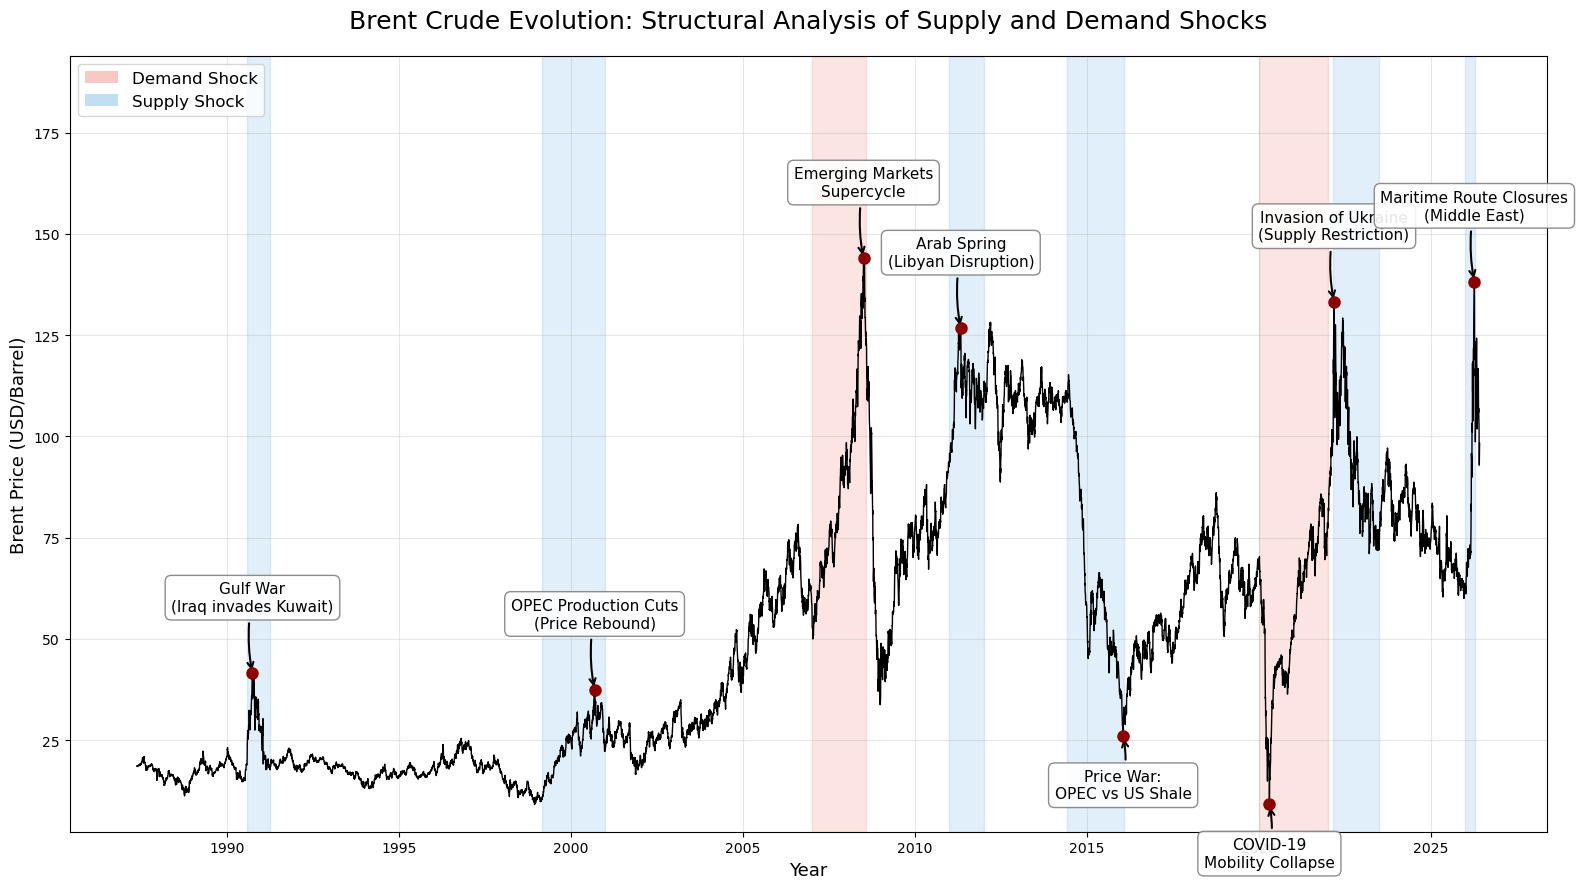

In [5]:

plt.figure(figsize=(16, 9))


sns.lineplot(data=brent_study, x=brent_study.index, y="Brent (Europe)", color="black", linewidth=1)


structural_shocks = [
    ('1990-08-01', '1991-03-31', 'Supply', 'max', 'Gulf War\n(Iraq invades Kuwait)'),
    ('1999-03-01', '2000-12-31', 'Supply', 'max', 'OPEC Production Cuts\n(Price Rebound)'), # Added 1999 OPEC Cuts
    ('2007-01-01', '2008-07-31', 'Demand', 'max', 'Emerging Markets\nSupercycle'),
    ('2011-01-01', '2011-12-31', 'Supply', 'max', 'Arab Spring\n(Libyan Disruption)'), 
    ('2014-06-01', '2016-01-31', 'Supply', 'min', 'Price War:\nOPEC vs US Shale'),
    ('2020-01-01', '2021-12-31', 'Demand', 'min', 'COVID-19\nMobility Collapse'),
    ('2022-02-24', '2023-06-30', 'Supply', 'max', 'Invasion of Ukraine\n(Supply Restriction)'),
    ('2026-01-01', '2026-04-12', 'Supply', 'max', 'Maritime Route Closures\n(Middle East)')
]

# Colors for the two types of shocks
shock_colors = {'Demand': '#e74c3c', 'Supply': '#3498db'} # Red for Demand, Blue for Supply

# 4. Process each shock: shade background, find extreme point, and annotate
for start, end, shock_type, extreme, text in structural_shocks:
    start_dt = pd.to_datetime(start)
    end_dt = pd.to_datetime(end)
    
    # --- A. Shade the background ---
    plt.axvspan(start_dt, end_dt, color=shock_colors[shock_type], alpha=0.15)
    
    # --- B. Find the maximum or minimum point ---
    mask = (brent_study.index >= start_dt) & (brent_study.index <= end_dt)
    period_data = brent_study.loc[mask, 'Brent (Europe)']
    
    if not period_data.empty:
        if extreme == 'max':
            extreme_date = period_data.idxmax()
            extreme_val = period_data.max()
            offset_y = 45  # Push the arrow further up to avoid crowding the line
        else:
            extreme_date = period_data.idxmin()
            extreme_val = period_data.min()
            offset_y = -45 # Push the arrow further down
            
        # --- C. Draw the dot ---
        plt.plot(extreme_date, extreme_val, marker='o', color='darkred', markersize=8, zorder=5)
        
        # --- D. Add the arrow and explanation text ---
        plt.annotate(
            text,
            xy=(extreme_date, extreme_val),
            xytext=(0, offset_y),
            textcoords='offset points',
            ha='center',
            fontsize=11,
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.9),
            arrowprops=dict(arrowstyle="->", color="black", linewidth=1.5, connectionstyle="arc3,rad=0.1")
        )

# 5. Expand the Y-axis limit to prevent title overlap
current_max_price = brent_study['Brent (Europe)'].max()
plt.ylim(top=current_max_price + 50) 

# 6. Custom Legend
legend_elements = [Patch(facecolor=shock_colors['Demand'], alpha=0.3, label='Demand Shock'),
                   Patch(facecolor=shock_colors['Supply'], alpha=0.3, label='Supply Shock')]
plt.legend(handles=legend_elements, loc='upper left', fontsize=12, frameon=True, facecolor='white')

# 7. Final Aesthetics
plt.title("Brent Crude Evolution: Structural Analysis of Supply and Demand Shocks", fontsize=18, pad=20)
plt.ylabel("Brent Price (USD/Barrel)", fontsize=13)
plt.xlabel("Year", fontsize=13)
plt.grid(visible=True, alpha=0.3)
plt.tight_layout()

plt.show()

### Oil Turning Points

It is also of great relevance a Turning Point analysis. For that porpouse, we will employ Harding and Pagan (2002) algorithm.

In [6]:
from auxi.descriptive import  identify_brent_turning_points

In [7]:
brent_study["Brent (Europe)"]

1987-05-20     18.63
1987-05-21     18.45
1987-05-22     18.55
1987-05-25     18.60
1987-05-26     18.63
               ...  
2026-05-26    102.75
2026-05-27     97.11
2026-05-28     95.47
2026-05-29     92.88
2026-06-01     98.29
Freq: B, Name: Brent (Europe), Length: 10184, dtype: float64

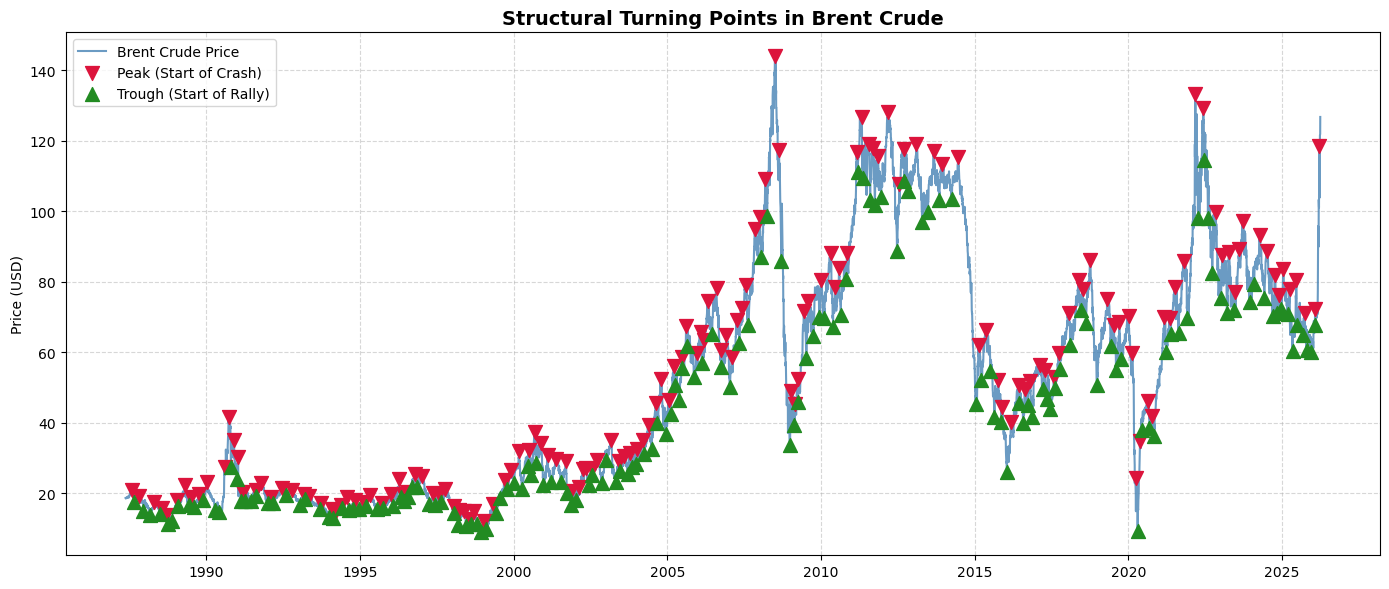

In [20]:
peaks, troughs = identify_brent_turning_points(brent_study["Brent (Europe)"].dropna(), min_distance_days=30, min_prominence_pct=0.05)

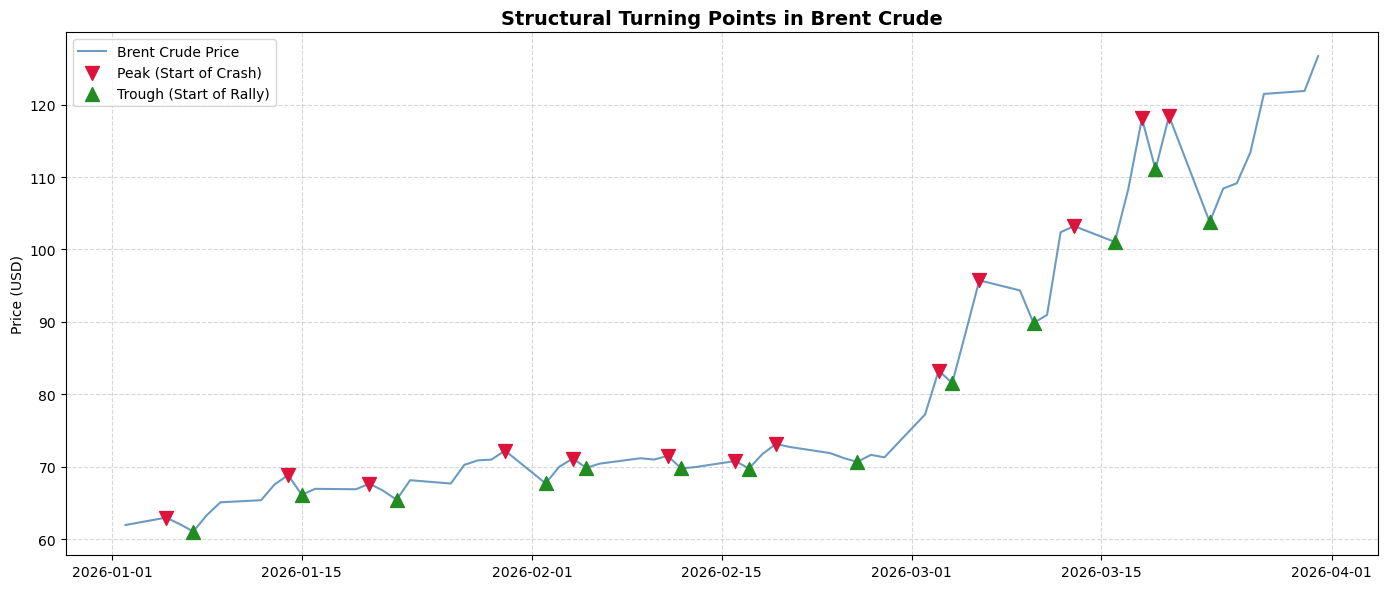

In [25]:

brent_window = brent_study.loc["01-01-2026":]
peaks, troughs = identify_brent_turning_points(brent_window["Brent (Europe)"].dropna(), min_distance_days=1, min_prominence_pct=0.01)

# Oil Volatility Data

In [10]:
# -- We have to truncate the sample in order for the missing days in April 2026 not to bias the metrics --

brent_study = brent_study[brent_study.index < '2026-04-01']

We will compute 2 volatily measures:
1. **Realized variance**: we will agregate the daily variation that occured within a specific month, avoiding the overalapping of roling windows:

    First we comute the daily log returns to be consistent with the previous transformations:


    $$r_{t} = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

    Then we group by the month starting date, by adding all the square monthly return of each month. Aditionally, we may compute the square root of the RV to have the RStd.

    $$RV_m = \sum_{i=1}^{N_m} r_{i,m}^2$$

2. **Annualized monthly standard deviation**: If you want a metric that is easily interpretable as a standard "volatility" figure (like the VIX), you can calculate the sample standard deviation of the daily returns within each month and annualize it:
    
    First we compute the daily log-returns just like we did before

    $$r_{t} = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

    Then we compute the monthly standard deviation of those returns (grouping by month) and we multiply by the square root of 252 to annualize the figure:

    $$\sigma_m = \text{Stdev}(r_{1:N, m}) \times \sqrt{252}$$
     
     




In [11]:
brent_study.dropna(inplace=True)


# 1. Calculate daily logarithmic returns
# log(P_t / P_{t-1})
daily_returns = np.log(brent_study / brent_study.shift(1))

# 2. Compute the transformations by resampling to Monthly ('ME') frequency
# Method A: Realized Variance (Sum of squared daily returns in that month)
# Note: pandas .sum() automatically ignores NaNs, which is great for your dataset
realized_variance = daily_returns.resample("MS").apply(lambda x: (x**2).sum())

# Method B: Realized Volatility (Square root of Realized Variance)
realized_volatility = np.sqrt(realized_variance)

# Method C: Annualized Monthly Standard Deviation
# Note: pandas .std() uses ddof=1 (sample standard deviation) by default
annualized_std = daily_returns.resample('MS').std() * np.sqrt(252)

# 3. Combine the targeted metrics into the requested dataframe
brent_mvar = pd.DataFrame({
    'Brent_Realized_Variance': realized_variance['Brent (Europe)'],
    'Brent_Realized_Volatility': realized_volatility['Brent (Europe)'],
    'Brent_Ann_StdDev': annualized_std['Brent (Europe)']
})


# Drop the first row if it's NaT/NaN due to the initial shift() calculation
brent_mvar = brent_mvar.dropna(subset=['Brent_Realized_Volatility'])



array([<Axes: >, <Axes: >, <Axes: >], dtype=object)

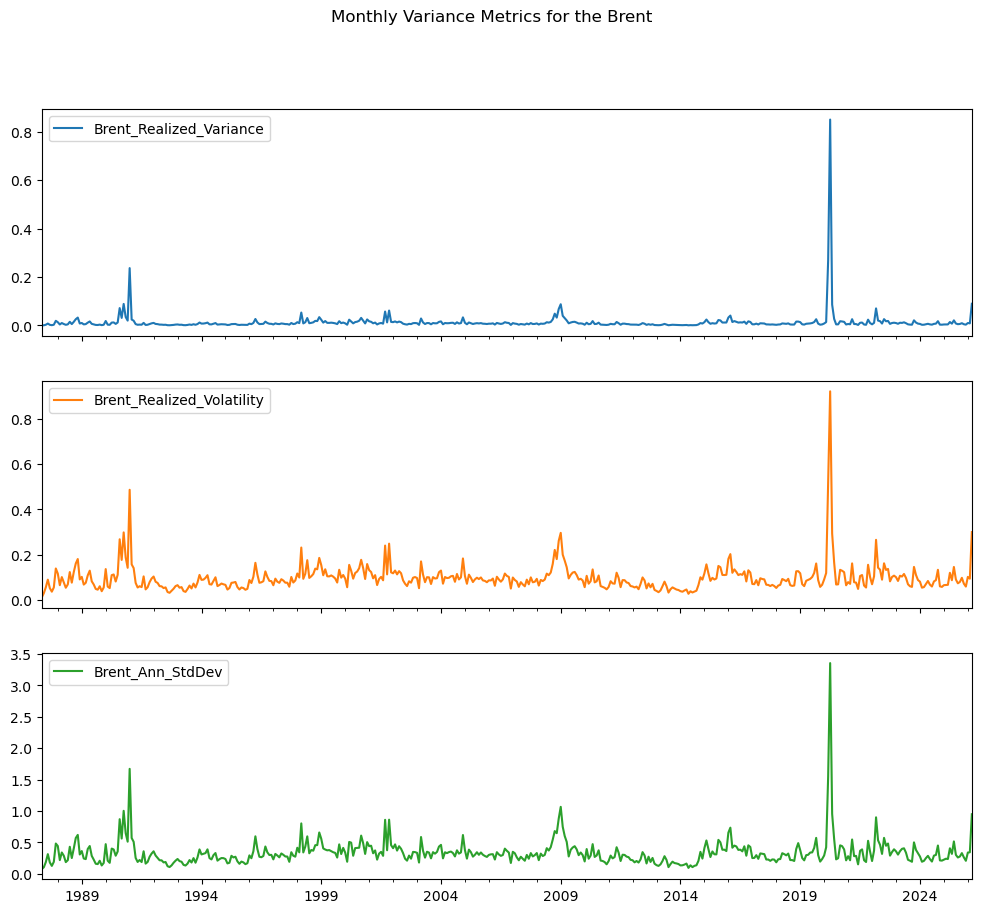

In [12]:
brent_mvar.plot(figsize=(12,10), title="Monthly Variance Metrics for the Brent", subplots=True)

Pending transformations to test:

- OVXCLS: implied volatility of crude oil ETF (USO), computed using the option prices. It is published by the CBOE and ghathered by Fred.

- Net oil prices: transformation proposed by Hamilton (2003)

- Price uncertainty: Jurado et al (2015)

- Net Returns: absolute value of the returns, easier but maybe more reliable than the previous transformations

# Time series transformations

From this analisis we conclude that we will work with log-diff data, which will make the time series stationary and will resamble the data to rates of changes. We will not only work with daily rates of changes but also with monthly rates of changes. \
\
For this, we will resample the data to take the first price of each month (to resample the GPR measurment), and we will compute the log-diff from those monthly prices.\
\
For the missing values, they are random and most of them are due to holidays. Therefore, we will procede with the dropping of this values.

### Missing values

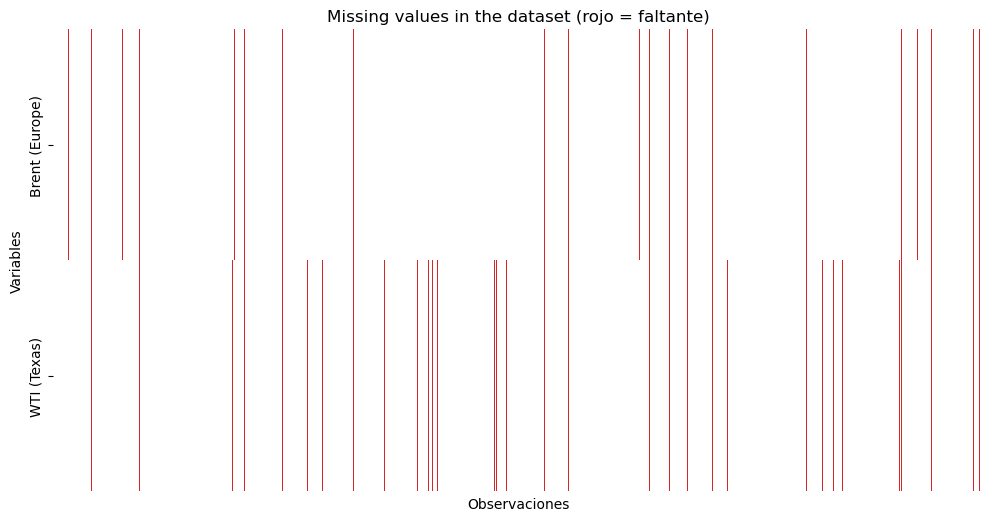

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Assuming your dataframe is named oil_prices from the previous step. 
# If you kept the name 'brent', just change 'oil_prices' back to 'brent' below!

plt.figure(figsize=(12,6))
cmap = ListedColormap(['#ffffff', '#d62728'])  # blanco = no falta, rojo = falta

# Removed linewidths so the daily data is actually visible!
sns.heatmap(oil_prices.T.isna(), cmap=cmap, cbar=False) 

plt.title("Missing values in the dataset (rojo = faltante)")
plt.xlabel("Observaciones")
plt.xticks([]) # Hides the x-axis ticks to keep it clean
plt.ylabel("Variables")

plt.show()

In [14]:
# --- Percentage of missing values on the original panel of data ---
oil_prices.isna().sum() /len(oil_prices)

Brent (Europe)    0.027690
WTI (Texas)       0.035153
dtype: float64

In [15]:
# -- Missing values y número de observaciones por año --

brent = oil_prices["Brent (Europe)"]

mv_yearly = (
    brent.isna()
    .groupby(oil_prices.index.year)
    .sum()
    .rename("Missing")
)

obs_yearly = (
    brent.groupby(oil_prices.index.year)
    .size()
    .rename("N_obs")
)

df_yearly = (
    pd.concat([mv_yearly, obs_yearly], axis=1)
    .reset_index()
    .rename(columns={"index": "Year"})
)

df_yearly["N_obs"].mean()


254.6

In [16]:
oil_prices = oil_prices.dropna()

### Stationarization

Time series are not stationary by default at 1% confidence level, but the first difference of the time series is. Since we are working with prices, we will work with the changes in prices (first difference). Moreover, we can observe some hetersokedasticity on the data, so we wi will work with the first difference of the logs of the time series.

Note: the ADF has been perfomed including only a constant in the Augmented ECM.

In [17]:
print("ADF on the series in levels: ")
aux.adf_test_all(oil_prices, signif=0.05)

ADF on the series in levels: 


NameError: name 'aux' is not defined

In [ ]:
print("ADF on the series in 1st differences: ")
aux.adf_test_all(oil_prices.diff(), signif=0.01)

ADF on the series in 1st differences: 


,ADF Statistic,p-value,Stationary
Brent (Europe),-15.052678,0.0,True
WTI (Texas),-13.651012,0.0,True


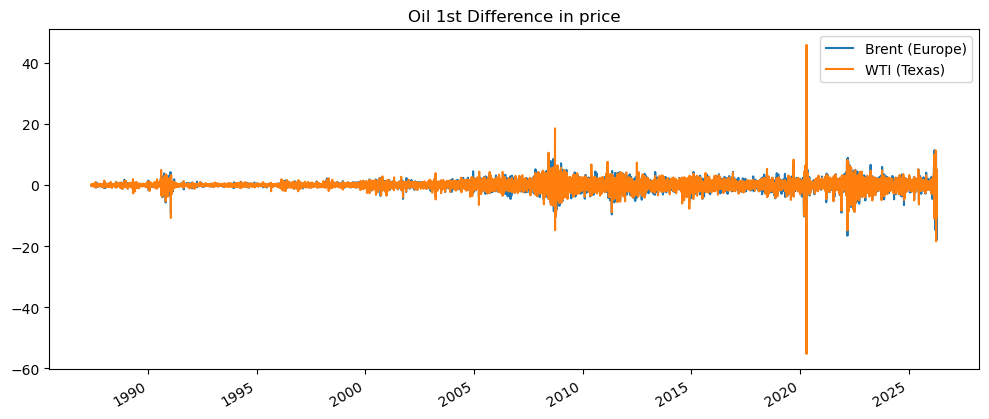

In [ ]:
# --- Plot of the first difference of the time series ---

oil_prices.diff().plot(figsize = (12,5), title = "Oil 1st Difference in price")
plt.show()

In [ ]:
# # --- Plot of the first difference of the time series ---

# oil_prices["Brent (Europe)"].diff().plot(figsize = (12,5), title = "Oil 1st Difference in price, Brent Europe")
# plt.show()

c:\Users\Alejandro\anaconda3\Lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


<Axes: title={'center': 'Oil 1st Difference of the log of the prices (Daily Rate of change of the prices)'}>

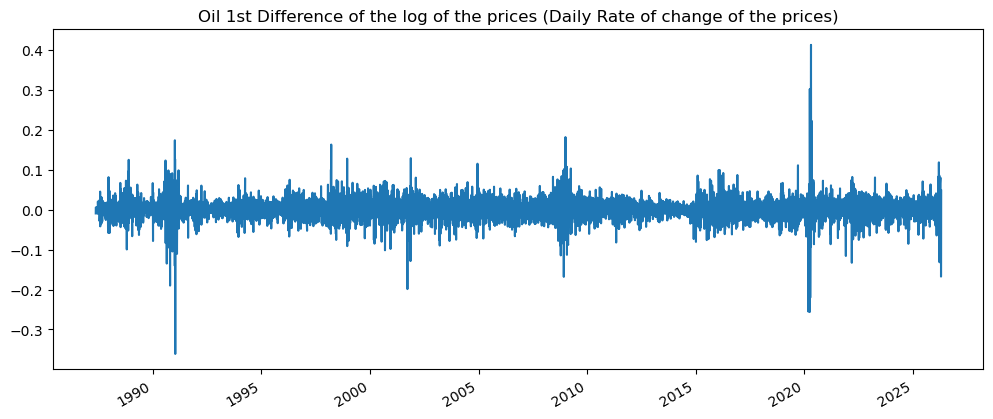

In [ ]:
d_ln_oil_prices = np.log(oil_prices).diff()
d_ln_oil_prices.dropna(inplace=True)

# --- Plot of the first difference of the log  the time series ---

d_ln_oil_prices["Brent (Europe)"].plot(figsize = (12,5), title = "Oil 1st Difference of the log of the prices (Daily Rate of change of the prices)")

## Month average vs Month first day

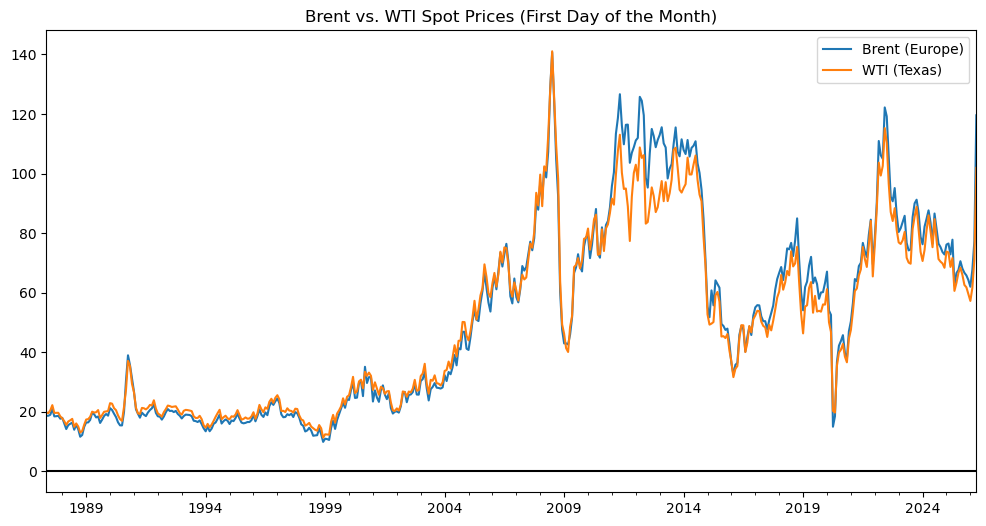

In [ ]:
oil_prices_m = oil_prices.resample("MS").first ()
oil_prices_m.plot(figsize=(12, 6), title="Brent vs. WTI Spot Prices (First Day of the Month)")
plt.axhline(0, color = "black")

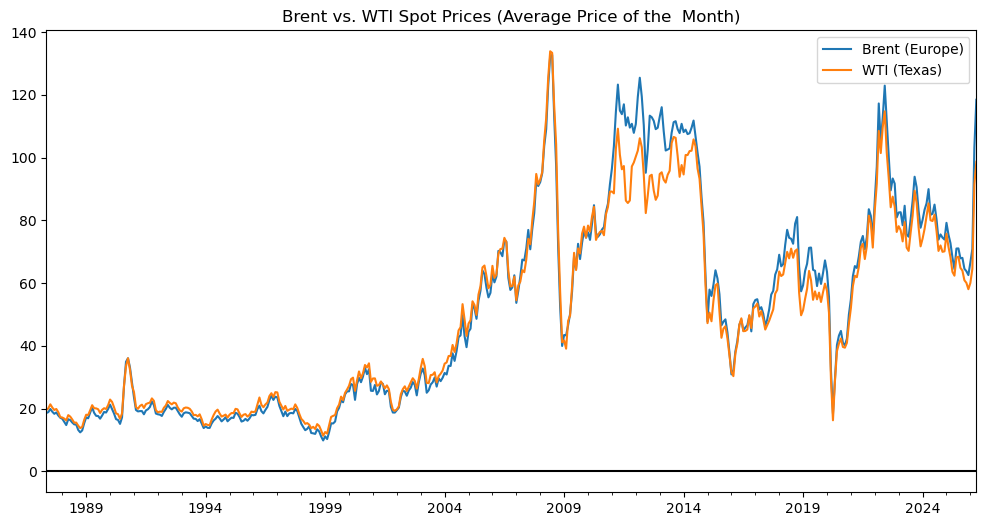

In [ ]:
oil_prices_m = oil_prices.resample("ME").mean()
oil_prices_m.plot(figsize=(12, 6), title="Brent vs. WTI Spot Prices (Average Price of the  Month)")
plt.axhline(0, color = "black")

# Rolling Windows

Instead of a monthly average, we can try to compute 3M averages by using a rolling window, this will gives us how the average of the last 90, 180 and 360 days changes over tieme.\
\
For that we will have to transform our data. The steps to follow are the following:
1. Resample to monthly data, computing the month average price (1a) or taking the first value of the month (1b)
2. Compute the MoM rate of change (2a) or the log diff (2b)
3. Compute a rolling average of the MoM changes.

We wil try to compute this using different procedures for step 1 and step 2.

### Resampling With averages

<Axes: title={'center': 'Brent Prices Rolling Means (AVG - PCTG)'}>

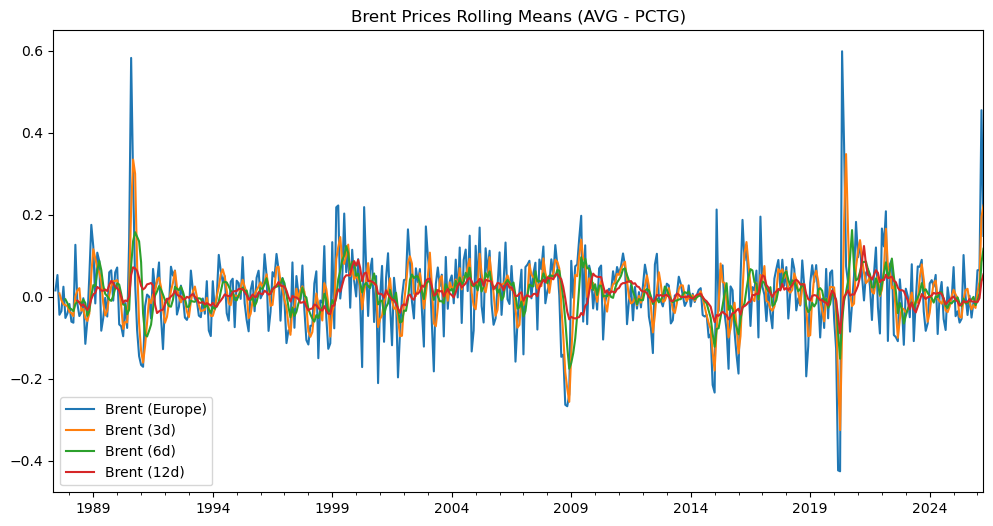

In [ ]:
brent = oil_prices["Brent (Europe)"].to_frame()

brent_m = brent.resample("MS").mean() # Resample to month average prices
brent_m_pctg = brent_m.pct_change() # Compute the MoM percentage changes

# Compute the rolling windows

windows = [3, 6, 12]

for w in windows:
    brent_m_pctg[f"Brent ({w}d)"] = brent_m_pctg["Brent (Europe)"].rolling(w).mean()

brent_m_pctg.plot(title="Brent Prices Rolling Means (AVG - PCTG)", figsize=(12,6), subplots=False)    

In [ ]:
brent_m_pctg.head()

,Brent (Europe),Brent (3d),Brent (6d),Brent (12d)
1987-05-01,NaN,NaN,NaN,NaN
1987-06-01,0.015252,NaN,NaN,NaN
1987-07-01,0.052811,NaN,NaN,NaN
1987-08-01,-0.044167,0.007965,NaN,NaN
1987-09-01,-0.035108,-0.008821,NaN,NaN


<Axes: title={'center': 'Brent Prices Rolling Means (AVG - LDIFF)'}>

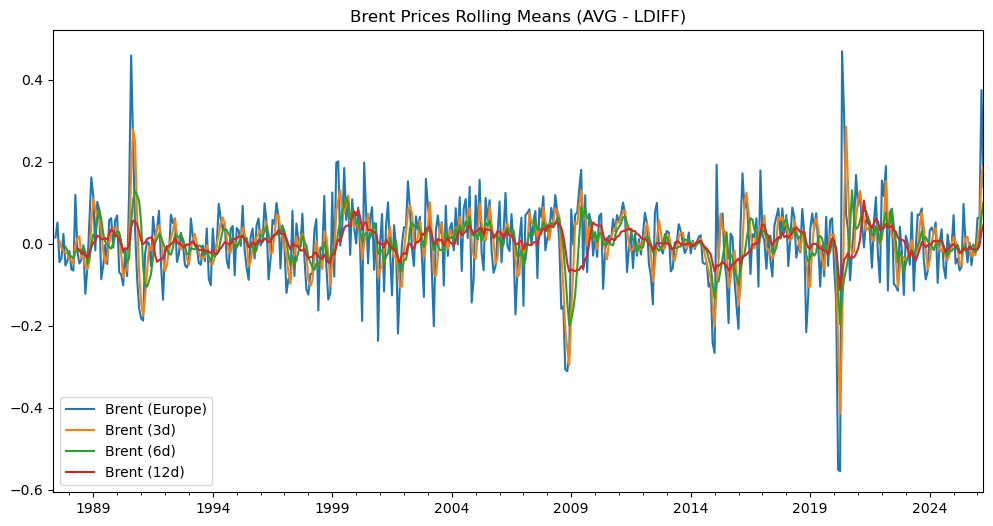

In [ ]:
brent = oil_prices["Brent (Europe)"].to_frame()

brent_m = brent.resample("MS").mean() # Resample to month average prices
brent_m_ld = np.log(brent_m).diff() # Compute the MoM percentage changes

# Compute the rolling windows

windows = [3, 6, 12]

for w in windows:
    brent_m_ld[f"Brent ({w}d)"] = brent_m_ld["Brent (Europe)"].rolling(w).mean()

brent_m_ld.plot(title="Brent Prices Rolling Means (AVG - LDIFF)", figsize=(12,6), subplots=False)    


### Resampling with the first value of the month

<Axes: title={'center': 'Brent Prices Rolling Means (FD - PCTG)'}>

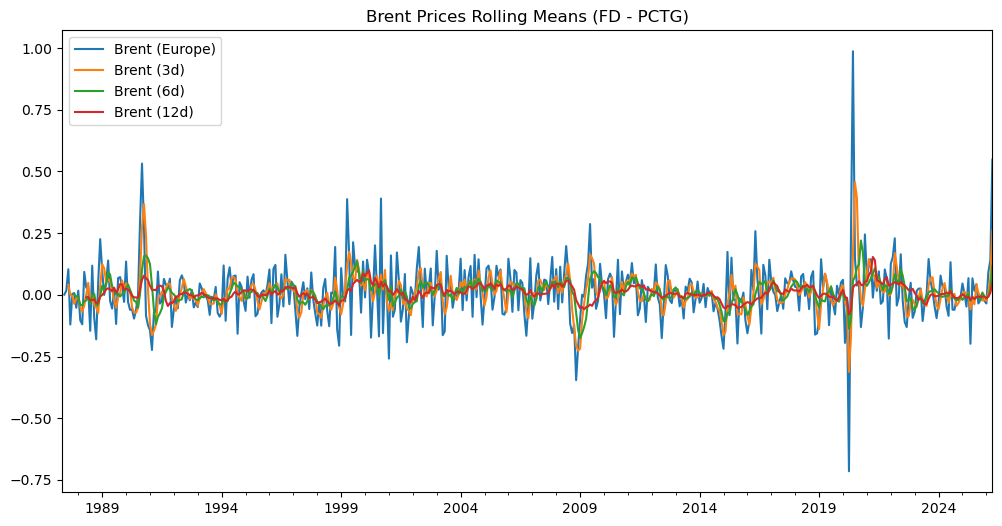

In [ ]:
brent = oil_prices["Brent (Europe)"].to_frame()

brent_m = brent.resample("MS").first() # Resample to month first price
brent_m_pctg = brent_m.pct_change() # Compute the MoM percentage changes

# Compute the rolling windows

windows = [3, 6, 12]

for w in windows:
    brent_m_pctg[f"Brent ({w}d)"] = brent_m_pctg["Brent (Europe)"].rolling(w).mean()

brent_m_pctg.plot(title="Brent Prices Rolling Means (FD - PCTG)", figsize=(12,6), subplots=False)    

<Axes: title={'center': 'Brent Prices Rolling Means (FD - LDIFF)'}>

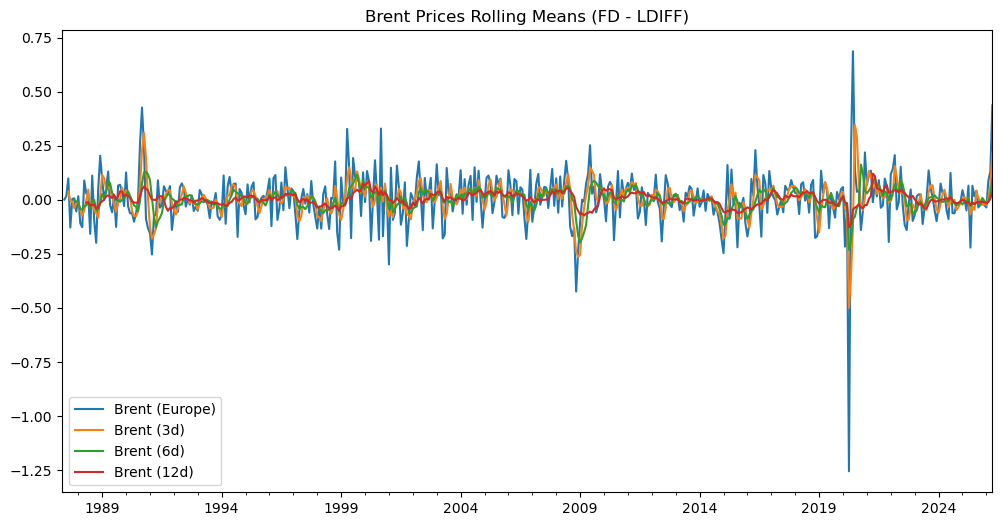

In [ ]:
brent = oil_prices["Brent (Europe)"].to_frame()


brent_m = brent.resample("MS").first() # Resample to month first price
brent_m_ld = np.log(brent_m).diff() # Compute the MoM percentage changes

# Compute the rolling windows

windows = [3, 6, 12]

for w in windows:
    brent_m_ld[f"Brent ({w}d)"] = brent_m_ld["Brent (Europe)"].rolling(w).mean()

brent_m_ld.plot(title="Brent Prices Rolling Means (FD - LDIFF)", figsize=(12,6), subplots=False)    